<a href="https://colab.research.google.com/github/KaisarJamil/Deep-unrolling_KSVD/blob/Master/ksvd_v_1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

font_path = u'/Library/Fonts/ヒラギノ角ゴ Pro W3.otf'
font_prop = FontProperties(fname=font_path)
#plt.rc('font',family=font_prop.get_name())

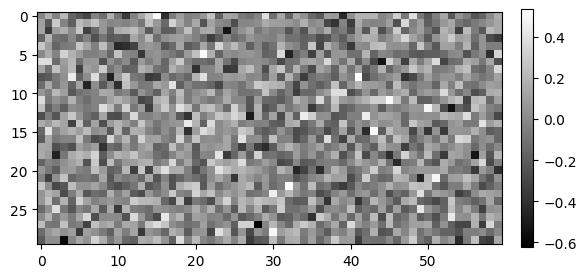

In [ ]:
A0 = np.random.randn(30, 60)
A0 = np.dot(A0, np.diag(1. / np.sqrt(np.diag(np.dot(A0.T, A0)))))

plt.imshow(A0, cmap='gray', interpolation='Nearest')
plt.colorbar(fraction=0.024, pad=0.04)

(0.0, 29.0)

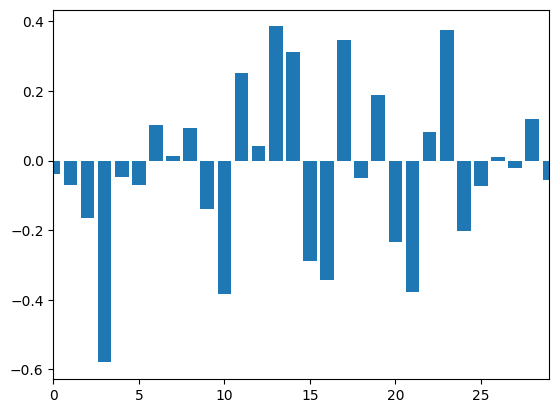

In [ ]:
Y = np.zeros((30, 4000))
sig = 0.1
k0 = 4
for i in range(4000):
    Y[:, i] = np.dot(A0[:, np.random.permutation(range(60))[:k0]], np.random.randn(4)) + np.random.randn(30) * sig

plt.bar(range(30), Y[:, 0])
plt.xlim(0, 29)

### 0.2 OMP algorithm

In [ ]:
def OMP(A, b, k0, eps):
    """
    直交マッチング追跡(orthogonal matching pursuit; OMP)

    A nxm行列
    b n要素の観測 corresponding to one patch(col)
    k0 xの非ゼロの要素数
    eps 誤差の閾値

    Inputs:
    A: An nxm matrix representing the Dictionary.
    b: An n-element vector representing the observed data.
    k0: The desired number of non-zero elements in the sparse representation.
    eps: The error threshold.

    Outputs:
    x: The sparse representation of the data.
    S: The support vector indicating the indices of the non-zero elements in x.
    """

    # 初期化
    x = np.zeros(A.shape[1]) #sparse reprentation
    S = np.zeros(A.shape[1], dtype=np.uint8)
    # print(f"x and S :", x, S)
    r = b.copy()
    rr = np.dot(r, r)
    for _ in range(k0):
        # 誤差計算
        err = rr - np.dot(A[:, S == 0].T, r) ** 2

        # サポート更新 Find the index of the minimum error in err among the elements
        ndx = np.where(S == 0)[0]
        S[ndx[err.argmin()]] = 1

        # 解更新 Extract the columns of dictionary A where sparse S = 1
        As = A[:, S == 1]
        pinv = np.linalg.pinv(np.dot(As, As.T))
        x[S == 1] = np.dot(As.T, np.dot(pinv, b))

        # 残差更新
        r = b - np.dot(A, x)
        rr = np.dot(r, r)
        if rr < eps:
            break

    return x, S



## Deep Unrolling Model

### 1.1 OMP Neural Network

In [ ]:
import torch
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"

class OMP_NETWORK(nn.Module):
    def __init__(self, A, b, k0, eps):
      super(OMP_NETWORK, self).__init__()
      print("OMP network has been initialized...")

      self.k0 = k0
      self.eps = eps

      #  初期化 (Initialization)


    # 誤差計算 (Error calculation)
    def error_cal(self, A, r, rr):
      return rr - torch.dot(A[:, S == 0].T, r) ** 2

    # サポート更新 (Find the index of the minimum error in err among the elements)
    def min_error_ndx(self):
      return torch.where(S == 0)[0]

    def forward(self, A, b):
      x = torch.zeros(A.shape[1])
      S = torch.zeros(A.shape[1], dtype=torch.uint8)
      # 初期化
      r = b.clone()
      rr = torch.dot(r, r)

      # print(f"A : {A.shape}\n, b : {b}\n, r : {r.shape}\n, rr : {rr}") #-ok
      for _ in range(self.k0):
        err = rr - torch.matmul(A[:, S == 0].t(), r).pow(2)
        ndx = self.min_error_ndx()

        min_indices = ndx[err.argmin()] if len(ndx) > 0 else None
        if min_indices is not None:
            S[min_indices] = 1

        # self.S[ndx[err.argmin()]] = 1

        # 解更新 (Extract the columns of dictionary A where sparse S = 1)
        As = A[:, S == 1]
        pinv = torch.linalg.pinv(torch.matmul(As, As.T))
        x_update = torch.matmul(As.t(), torch.matmul(pinv, b))
        self.x.data[S == 1] = x_update

        # 残差更新
        r = b - torch.matmul(A, self.x)
        if rr < self.eps:
            break

        # print(f"The value of x : {self.x}, The value of S : {self.S}")
        return x, S;


In [ ]:
#訓練ループ(Training loop)

def run_unfolding_omp(A, b, k0, eps):

  # Convert numpy arrays to PyTorch tensors
  A_tensor = torch.from_numpy(A).float()
  b_tensor = torch.from_numpy(b).float()

  # print(f"A_tensor : {A_tensor.device}") -ok
  A_tensor, b_tensor = A_tensor.to(device), b_tensor.to(device)

  # print(f"A_tensor : {A_tensor.device}") -ok
  # Create an instance of the OMP model
  omp_model = OMP_NETWORK(A_tensor, b_tensor, k0, eps).to(device);
  # print(f"omp_model : {A_tensor.device}")

  # Setup loss function
  loss_fn = nn.MSELoss()

  # Setup optimizer
  optimizer = torch.optim.SGD(omp_model.parameters(), lr=0.1)

  # Training loop
  epochs = 100

  for epoch in range(epochs):

    # Set the model in training mode
    omp_model.train()
    # print(f"Epoch ok --> {epoch}") #-ok

    # 1. Forward pass
    x, S = omp_model(A_tensor, b_tensor)
    # print(f"Return value from Forward pass step : {x, S}")

    # 2. Compute loss
    residual = b_tensor - torch.matmul(A_tensor, x)
    # print(f"residual ok --->") #-ok
    loss = torch.mean(torch.square(residual))

    # 3. Zero the gradients
    optimizer.zero_grad()

    # 4. Loss backward (perform backpropagation)
    loss.backward()

    # 5. Step the optimizer (gradient descent)
    optimizer.step()

    # Print loss for monitoring
    # print('Epoch [{}/{}], Loss: {:.4f}'.format(epoch+1, epochs, loss))

  # Get the final sparse representation and support
  x_final, S_final = omp_model(A_tensor, b_tensor)

  # print(f"x_final : {x_final}, S_final : {S_final}")

  x_final = x_final.cpu()
  S_final = S_final.cpu()

  # Convert tensors back to numpy arrays
  x = x_final.detach().numpy()
  S = S_final.detach().numpy()

  print(f"The data type and dim of x: {x.dtype, x.shape} \n The value of S : {S.dtype, S.shape}")
  print(f"The value of x: {x} \n The value of S : {S}")
  return x, S;




### 1.2 Updating Dictionary(A) Neural Network

## Dictionary Learning

### 0.3 ``DctionaryLearning()`` algorithm

In [ ]:
class DctionaryLearning(object):
    """ 辞書学習 """
    def MOD(self, Y, sig, m, k0, n_iter=50, A0=None, initial_dictionary=None):
        """
        MOD辞書学習アルゴリズム

        Y 信号事例、n×M、nは事例の次元、Mは事例の総数
        sig ノイズレベル
        m 辞書の列数
        k0 非ゼロ要素の個数
        """
        if initial_dictionary is None:
            A = Y[:, :m]
            A = np.dot(A, np.diag(1. / np.sqrt(np.diag(np.dot(A.T, A)))))
        else:
            A = initial_dictionary
        X = np.zeros((A.shape[1], Y.shape[1]))
        eps = A.shape[0] * (sig ** 2)

        log = []
        for k in range(n_iter):
            for i in range(Y.shape[1]):
                X[:, i], _ = OMP(A, Y[:, i], k0, eps=eps)

            opt = np.abs(Y - np.dot(A, X)).mean()

            A = np.dot(Y, np.dot(X.T, np.linalg.pinv(np.dot(X, X.T))))
            A = np.dot(A, np.diag(1. / np.sqrt(np.diag(np.dot(A.T, A)))))

            if A0 is not None:
                opt2 = self.percent_recovery_of_atoms(A, A0)
                log.append((opt, opt2))
            else:
                log.append(opt)
            print(k, log[k])

        return A, np.array(log)

    def KSVD(self, Y, sig, m, k0, n_iter=50, A0=None, initial_dictionary=None):
        """
        K-SVD辞書学習アルゴリズム

        Y 信号事例、n×M、nは信号の次元、Mは事例の総数
        sig ノイズレベル error hyper-parameter
        m 辞書の列数
        k0 非ゼロ要素の個数 the # non zero co-efficient

        参考
        https://github.com/greyhill/pypbip/blob/master/ksvd.py
        """
        if initial_dictionary is None:
            A = Y[:, :m]
            A = np.dot(A, np.diag(1. / np.sqrt(np.diag(np.dot(A.T, A)))))
        else:
            A = initial_dictionary
        X = np.zeros((A.shape[1], Y.shape[1]))
        eps = A.shape[0] * (sig ** 2)

        ndx = np.arange(m)
        log = []
        for k in range(n_iter):
            for i in range(Y.shape[1]):
                X[:, i], _ = run_unfolding_omp(A, Y[:, i], k0, eps=eps)

            for j in ndx:
                x_using = X[j, :] != 0
                if np.sum(x_using) == 0:
                    continue
                X[j, x_using] = 0
                Residual_err = Y[:, x_using] - np.dot(A, X[:, x_using])
                U, s, Vt = np.linalg.svd(Residual_err)
                A[:, j] = U[:, 0]
                X[j, x_using] = s[0] * Vt.T[:, 0]

            opt = np.abs(Y - np.dot(A, X)).mean()
            if A0 is not None:
                opt2 = self.percent_recovery_of_atoms(A, A0)
                log.append((opt, opt2))
            else:
                log.append(opt)
            print(k, log[k])

        return A, np.array(log)

    def percent_recovery_of_atoms(self, A, A0, threshold=0.99):
        """ アトムの復元率を測る """
        num = 0
        for m in range(A.shape[1]):
            a = A0[:, m]
            if np.abs(np.dot(a, A)).max() > threshold:
                num += 1
        return float(num) / A.shape[1] * 100

### 0.4 Dictionary learning

In [ ]:
dl = DctionaryLearning()
# A_MOD, log_MOD = dl.MOD(Y, sig, A0.shape[1], k0, A0=A0, n_iter=50)
A_KSVD, log_KSVD = dl.KSVD(Y, sig, A0.shape[1], k0, A0=A0, n_iter=50)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(log_MOD[:, 0], label='MOD')
ax[0].plot(log_KSVD[:, 0], ls='--', label='K-SVD')
ax[0].set_ylabel('Mean Absolute Error (MAE)')
ax[0].set_xlabel('Number of Iterations')
ax[0].legend(loc='best')
ax[0].grid()
ax[1].plot(log_MOD[:, 1], label='MOD')
ax[1].plot(log_KSVD[:, 1], ls='--', label='K-SVD')
ax[1].set_ylabel('Percentage of Recontruction Atoms')
ax[1].set_xlabel('Number of Iterations')
ax[1].legend(loc='best')
ax[1].grid()
plt.savefig('MOD_K-SVD.png', dpi=220)

## 1. K-SVD

### 1.1 Import the image

In [ ]:
from skimage.io import imread

im = imread('barbara.png').astype(np.float)

plt.imshow(im, cmap='gray', interpolation='Nearest')
plt.axis('off')

In [ ]:
print(im.shape[0])
print(im.shape[1])

### 1.2 Convert the image into patches

In [ ]:
patch_size = 8
patches = []
for row in range(im.shape[0] - patch_size + 1):
    for col in range(im.shape[1] - patch_size + 1):
        # print(f"In raw loop:", im.shape[0] - patch_size + 1)
        patches.append(im[row:row + patch_size, col:col + patch_size])
patches = np.array(patches)
print(f"Patches are printed here -->", patches.shape)

n = 8
sample = patches[np.random.permutation(patches.shape[0])[:n ** 2]]
sample = sample.reshape((n, n, patch_size, patch_size))
patch_work = np.swapaxes(sample, 1, 2).reshape((n * patch_size, n * patch_size))

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(im, cmap='gray', interpolation='Nearest')
ax[0].axis('off')
ax[0].set_title('Original image for evaluating dictionary learning - Barbara')
ax[1].imshow(patch_work, cmap='gray', interpolation='Nearest')
ax[1].axis('off')
ax[1].set_title('Part of the extracted patch')
plt.tight_layout()
plt.savefig('barbara_patches.png', dpi=220)

### 1.3 Get the dictionary

In [ ]:
A_1D = np.zeros((8, 11))
for k in np.arange(11):
    for i in np.arange(8):
        A_1D[i, k] = np.cos(i * k * np.pi / 11.)
    if k != 0:
        A_1D[:, k] -= A_1D[:, k].mean()

A_2D = np.kron(A_1D, A_1D)

def show_dictionary(A, name=None):
    """ Show dictionary """
    n = int(np.sqrt(A.shape[0]))
    m = int(np.sqrt(A.shape[1]))
    A_show = A.reshape((n, n, m, m))
    fig, ax = plt.subplots(m, m, figsize=(4, 4))
    for row in range(m):
        for col in range(m):
            ax[row, col].imshow(A_show[:, :, col, row], cmap='gray', interpolation='Nearest')
            ax[row, col].axis('off')
    if name is not None:
        plt.savefig(name, dpi=220)

show_dictionary(A_2D, name='dct_dictionary.png')

In [ ]:
A_2D.shape

In [ ]:
# Our image dictionary

Y = patches[::10].reshape((-1, 64)).swapaxes(0, 1) #converted vector
sig = 0
k0 = 4

dl = DctionaryLearning()
A_KSVD_barbara, log_KSVD_barbara = dl.KSVD(Y, sig, A_2D.shape[1], k0, n_iter=50, initial_dictionary=A_2D.copy())

show_dictionary(A_KSVD_barbara, name='ksvd_dictionary_barbara.png')

### 1.4 Visualize the loss and iteration

In [ ]:
plt.plot(log_KSVD_barbara, label='K-SVD')
plt.ylabel('Mean Absolute Error(MAE)')
plt.xlabel('Number of Iterations')
plt.legend(loc='best')
plt.grid()
plt.savefig('Barbara_K-SVD.png', dpi=220)